# VAR forecasting with Impulso

A vector autoregression models several series jointly: each series depends on
the past of every series, and the shocks are correlated. This notebook fits a
VAR(2) to the quarterly growth rates of US real GDP, consumption and
investment — the same series as the
[numpyro-forecast VAR example](https://juanitorduz.github.io/numpyro_forecast/docs/examples/var.html)
— and scores the forecasts with `backtest`.

The lag recursion, Minnesota prior and density forecast live in
[Impulso](https://impulso.quantclimate.com/). pymc-forecast does not grow a
VAR implementation for this example, and Impulso is not a core dependency:
it is installed with the `notebooks` and `docs` groups. Identification and
impulse responses stay in Impulso; they are not part of the forecast score.

In [1]:
import logging
import os
import warnings
from importlib.metadata import version

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from impulso import VAR, VARData
from impulso.priors import MinnesotaPrior
from impulso.samplers import NUTSSampler

from pymc_forecast import backtest, evaluate_forecast, null_covariates, results_to_dataframe
from pymc_forecast.metrics import eval_crps

logging.getLogger("pytensor").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="`nuts_sampler_kwargs` is deprecated.*", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message="Passing `log_likelihood` via `idata_kwargs` is deprecated.*",
    category=FutureWarning,
)

SMOKE = os.getenv("PYMC_FORECAST_SMOKE_TEST") == "1"
SEED = 2026
HOLDOUT = 8
DRAWS, TUNE, CHAINS = (25, 25, 1) if SMOKE else (500, 500, 2)
N_PRED = DRAWS * CHAINS
plt.rcParams.update({"figure.figsize": (10, 4), "figure.dpi": 110})
print("Execution mode:", "CI smoke check; do not interpret fit quality" if SMOKE else "full example")

Execution mode: full example


## Quarterly growth rates

`statsmodels` ships this macro panel. The VAR is fit to approximate quarterly
percent growth, `100 * Δ log`, not to the levels. Investment is the volatile
series; Impulso's Minnesota prior rescales cross-lags by each series' AR(1)
residual scale, so the three columns do not need to be standardised first.

In [2]:
MACRO_URL = (
    "https://raw.githubusercontent.com/statsmodels/statsmodels/"
    "main/statsmodels/datasets/macrodata/macrodata.csv"
)
raw = pd.read_csv(MACRO_URL)
dates = pd.PeriodIndex.from_fields(
    year=raw["year"].astype(int),
    quarter=raw["quarter"].astype(int),
    freq="Q",
).to_timestamp()
levels = raw[["realgdp", "realcons", "realinv"]].set_index(dates)
growth_frame = (100 * np.log(levels)).diff().dropna()
growth = xr.DataArray(
    growth_frame.to_numpy(),
    dims=("time", "series"),
    coords={"time": growth_frame.index, "series": list(growth_frame.columns)},
    name="growth",
)
growth.sizes

Frozen({'time': 202, 'series': 3})

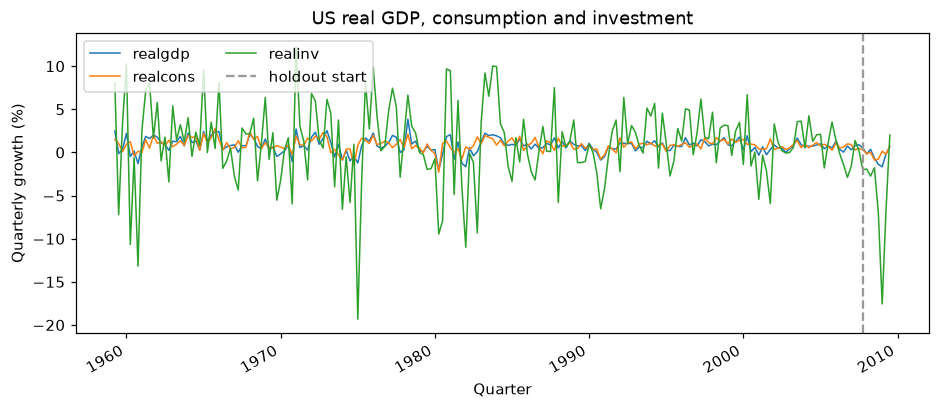

In [3]:
fig, ax = plt.subplots()
for name, color in zip(("realgdp", "realcons", "realinv"), ("C0", "C1", "C2"), strict=True):
    series = growth.sel(series=name)
    ax.plot(series.time, series, color=color, lw=1, label=name)
ax.axvline(growth.time.values[-HOLDOUT], color="0.6", ls="--", label="holdout start")
ax.set(xlabel="Quarter", ylabel="Quarterly growth (%)")
ax.set_title("US real GDP, consumption and investment")
ax.legend(loc="upper left", ncol=2)
fig.autofmt_xdate()
plt.show()

## A stationary Minnesota prior

Impulso's default Minnesota prior puts mean 1 on each series' own first lag:
a random walk. That centre is for levels. These series are growth rates, so
the own-lag mean is 0. Tightness, lag decay and cross-lag shrinkage stay at
the documented defaults (`0.1`, `"harmonic"`, `0.5`).

Two lags match the numpyro-forecast example. The specification is an Impulso
`VAR`, not a `ForecastingModel`: Impulso forecasts by iterating the posterior
coefficient draws in NumPy (`FittedVAR.forecast`), and that path is not a
`forecast` random variable `pm.sample_posterior_predictive` can replay.

In [4]:
spec = VAR(lags=2, prior=MinnesotaPrior(own_lag_mean=0.0))
spec

VAR(lags=2, max_lags=None, prior=MinnesotaPrior(tightness=0.1, decay='harmonic', cross_shrinkage=0.5, own_lag_mean=0.0), volatility='constant', exog_prior_scale=100.0, error_dist='gaussian')

## Adapter

`backtest` constructs `forecaster_cls(model, train, covariates, random_seed=..., **options)`
and reads `forecast(...)["predictions"]["forecast"]` with dims
`(chain, draw, time_future, series)`. The adapter fits only the training
slice, draws a density forecast (parameter uncertainty and future shocks;
Impulso's default), and relabels Impulso's `step` / `variable` axes onto the
held-out dates. `model` is the `VAR` specification. Covariates are unused
except as the horizon carrier, which is how `backtest` passes `None`.

In [5]:
def _group_dataset(idata, name):
    """Return an InferenceData group as a Dataset on ArviZ 0 and ArviZ 1."""
    group = idata[name]
    if isinstance(group, xr.Dataset):
        return group
    return group.to_dataset()


def _predictions_tree(forecast):
    dataset = xr.Dataset({"forecast": forecast})
    if int(version("arviz").split(".")[0]) >= 1:
        return xr.DataTree.from_dict({"predictions": dataset})
    return az.InferenceData(predictions=dataset)


def _thin_draws(draws, num_samples, seed):
    n_draws = draws.sizes["chain"] * draws.sizes["draw"]
    if num_samples > n_draws:
        msg = (
            f"num_samples={num_samples} exceeds the posterior size {n_draws} "
            f"({draws.sizes['chain']} chains x {draws.sizes['draw']} draws)"
        )
        raise ValueError(msg)
    if num_samples == n_draws:
        return draws
    stacked = draws.stack(sample=("chain", "draw"))
    index = np.sort(np.random.default_rng(seed).choice(n_draws, size=num_samples, replace=False))
    taken = stacked.isel(sample=index).transpose("sample", ...)
    other = [dim for dim in taken.dims if dim != "sample"]
    coords = {dim: taken.coords[dim] for dim in other if dim in taken.coords}
    return xr.DataArray(
        taken.values[None, ...],
        dims=("chain", "draw", *other),
        coords={"chain": [0], "draw": np.arange(num_samples), **coords},
        name=draws.name,
    )


class ImpulsoForecaster:
    """Fit an Impulso VAR on one window and forecast with ``FittedVAR.forecast``."""

    def __init__(self, model_fn, data, covariates, *, random_seed, draws, tune, chains):
        del covariates  # horizon carrier only; the fit uses the training slice
        if not isinstance(model_fn, VAR):
            msg = "ImpulsoForecaster expects an impulso.VAR specification as the model"
            raise TypeError(msg)
        frame = data.to_pandas()
        if not isinstance(frame.index, pd.DatetimeIndex):
            msg = f"training data must have a DatetimeIndex, got {type(frame.index).__name__}"
            raise TypeError(msg)
        self._train = data
        self.fitted = model_fn.fit(
            VARData.from_df(frame, endog=list(frame.columns)),
            sampler=NUTSSampler(
                draws=draws,
                tune=tune,
                chains=chains,
                cores=1,
                random_seed=int(random_seed),
                nuts_sampler="pymc",
                progressbar=False,
            ),
        )

    def forecast(self, covariates, num_samples, random_seed):
        horizon = covariates.sizes["time"] - self._train.sizes["time"]
        result = self.fitted.forecast(steps=horizon, seed=int(random_seed))
        draws = _thin_draws(
            _group_dataset(result.idata, "posterior_predictive")["forecast"],
            num_samples,
            random_seed,
        )
        future = covariates.isel(time=slice(-horizon, None))
        labeled = draws.rename(step="time_future", variable="series").assign_coords(
            time_future=("time_future", future.time.values),
            series=("series", list(result.var_names)),
        )
        return _predictions_tree(labeled)

    def predict_in_sample(self, num_samples, random_seed):
        del num_samples, random_seed
        msg = "this adapter scores Impulso's out-of-sample density forecast, not the in-sample fit"
        raise NotImplementedError(msg)

## One holdout

Fit on every quarter but the last eight, then forecast those eight. Those
eight quarters run through the 2008-09 collapse, so coverage on this fold
is not a calibration check. The summary is the reduced-form posterior (`B`
is lag-major: all series at lag 1, then all series at lag 2). The plotted
band is the central 90% of the density forecast, the same interval
`eval_coverage` scores.

In [6]:
train = growth.isel(time=slice(None, -HOLDOUT))
truth = growth.isel(time=slice(-HOLDOUT, None)).rename(time="time_future")
full_time = null_covariates(growth.time.values)
forecaster = ImpulsoForecaster(
    spec,
    train,
    full_time,
    random_seed=SEED,
    draws=DRAWS,
    tune=TUNE,
    chains=CHAINS,
)
summary = az.summary(forecaster.fitted.idata, var_names=["B", "intercept"])
sample_stats = _group_dataset(forecaster.fitted.idata, "sample_stats")
print("divergences:", int(sample_stats["diverging"].sum()))
summary

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, B, sigma_sd, tril_offdiag]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"B[realgdp, L1.realgdp]",0.087,0.054,-0.00042,0.17,865,691,1.00,0.0018,0.0016
"B[realgdp, L1.realcons]",0.071,0.049,-0.012,0.15,749,709,1.00,0.0018,0.0013
"B[realgdp, L1.realinv]",-0.0001,0.0075,-0.012,0.012,872,850,1.00,0.00025,0.00022
"B[realgdp, L2.realgdp]",0.039,0.036,-0.02,0.092,868,728,1.00,0.0012,0.0011
"B[realgdp, L2.realcons]",0.028,0.027,-0.016,0.069,1375,784,1.00,0.00072,0.00077
"B[realgdp, L2.realinv]",-0.0006,0.0041,-0.0073,0.0059,1148,866,1.00,0.00012,0.00011
"B[realcons, L1.realgdp]",0.029,0.035,-0.026,0.085,1213,749,1.00,0.00099,0.0011
"B[realcons, L1.realcons]",0.069,0.058,-0.024,0.16,847,823,1.00,0.002,0.0017
"B[realcons, L1.realinv]",0.0067,0.006,-0.0031,0.016,1414,690,1.00,0.00016,0.00018
"B[realcons, L2.realgdp]",0.0073,0.0175,-0.023,0.035,1263,760,1.00,0.00049,0.00048


In [7]:
pred = forecaster.forecast(full_time, num_samples=N_PRED, random_seed=SEED + 1)
forecast = pred["predictions"]["forecast"]
assert forecast.dims == ("chain", "draw", "time_future", "series")
pd.Series(evaluate_forecast(forecast, truth))

mae         2.672991
rmse        4.747424
crps        2.019383
coverage    0.625000
dtype: float64

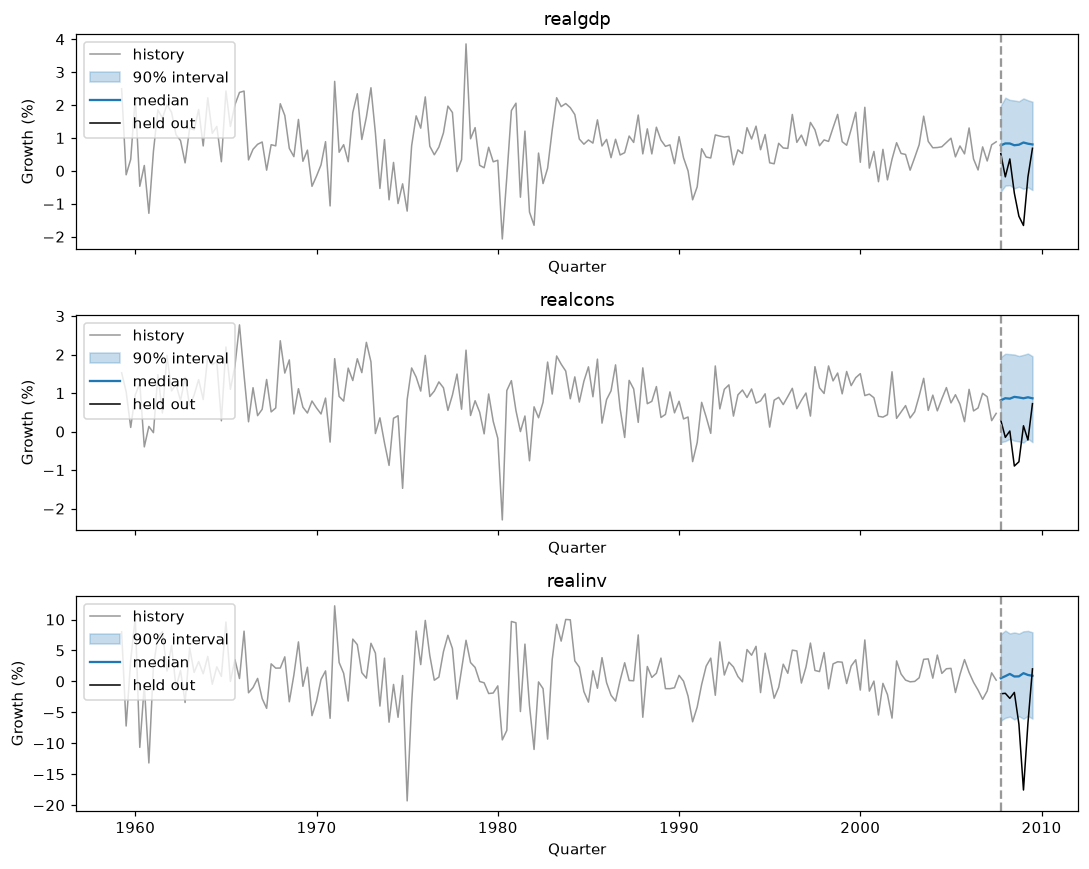

In [8]:
def plot_series(ax, samples, observed, holdout, title):
    q = samples.quantile([0.05, 0.5, 0.95], dim=("chain", "draw"))
    time = samples.time_future.values
    ax.plot(observed.time, observed, color="0.6", lw=1, label="history")
    ax.fill_between(
        time,
        q.sel(quantile=0.05),
        q.sel(quantile=0.95),
        color="C0",
        alpha=0.25,
        label="90% interval",
    )
    ax.plot(time, q.sel(quantile=0.5), color="C0", label="median")
    ax.plot(time, holdout.values, color="black", lw=1, label="held out")
    ax.axvline(time[0], color="0.6", ls="--")
    ax.set(title=title, xlabel="Quarter", ylabel="Growth (%)")
    ax.legend(loc="upper left")


fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, name in zip(axes, growth.series.values, strict=True):
    plot_series(
        ax,
        forecast.sel(series=name),
        train.sel(series=name),
        truth.sel(series=name),
        name,
    )
fig.tight_layout()
plt.show()

## Expanding-window backtest

Each fold refits on its own history and forecasts the next eight quarters.
The last two folds cover the end of the sample; the smoke check runs one.
Scores include the shock draws, so a tight interval here would mean the
adapter had dropped them.

In [9]:
window = {
    "min_train_window": growth.sizes["time"] - (1 if SMOKE else 2) * HOLDOUT,
    "test_window": HOLDOUT,
    "stride": HOLDOUT,
}
results = backtest(
    growth,
    None,
    spec,
    forecaster_cls=ImpulsoForecaster,
    num_samples=N_PRED,
    forecaster_options={"draws": DRAWS, "tune": TUNE, "chains": CHAINS},
    keep_predictions=True,
    random_seed=SEED + 2,
    **window,
)
results_to_dataframe(results)

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [intercept, B, sigma_sd, tril_offdiag]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sequential sampling (2 chains in 1 job)


NUTS: [intercept, B, sigma_sd, tril_offdiag]


Sampling 2 chains for 500 tune and 500 draw iterations (1_000 + 1_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


,t0,t1,t2,num_samples,train_walltime,test_walltime,mae,rmse,crps,coverage
0,0,186,194,1000,5.136934,0.002512,0.846631,1.343332,0.658235,1.000000
1,0,194,202,1000,2.600751,0.002628,2.642866,4.676621,1.989070,0.666667


In [10]:
per_series = []
for result in results:
    holdout = growth.isel(time=slice(result.t1, result.t2)).rename(time="time_future")
    per_series.append(
        {
            "t1": result.t1,
            **{
                str(name): evaluate_forecast(
                    result.prediction.sel(series=name),
                    holdout.sel(series=name),
                    metrics={"crps": eval_crps},
                )["crps"]
                for name in holdout.series.values
            },
        }
    )
pd.DataFrame(per_series)

,t1,realgdp,realcons,realinv
0,186,0.279234,0.238236,1.457235
1,194,0.835168,0.679294,4.452748


## What to inspect

Read the own-lag coefficients against the prior mean of 0, and check
divergences before treating the bands as calibrated. CRPS on eight quarters
is noisy; the per-series table is there to show that investment, not GDP, is
the hard series. This notebook does not identify shocks. For impulse
responses, use Impulso's identification API on `forecaster.fitted`.